<a href="https://colab.research.google.com/github/AakritiGuragain/-Image-Classification-Using-Deep-Learning/blob/main/fake_insta_using_kaggle_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment Setup & Matrix Ingestion

In [ ]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model training, split evaluation, and core metric modules
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Load the user-uploaded real CSV datasets directly from the execution workspace
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# DATA HYGIENE STEP: Strip out any trailing or leading spaces hidden within column titles
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

print(f"Data Schema Loaded Successfully.")
print(f"-> Ingested Training Dataset Matrix Shape: {train_df.shape[0]} profiles by {train_df.shape[1]} columns.")
print(f"-> Ingested Testing Dataset Matrix Shape:  {test_df.shape[0]} profiles by {test_df.shape[1]} columns.")

[System Core] Initializing and training background audience screening engines...
[System Core] Background models successfully loaded into notebook memory. Ready to audit.


# Exploratory Data Analysis

In [ ]:
print("="*35 + " EXPLORATORY DATA ANALYSIS (EDA) " + "="*35)

# 1. Structural Class Imbalance Auditing
train_splits = train_df['fake'].value_counts()
test_splits = test_df['fake'].value_counts()
print(f"[Class Split Analysis] Training Setup: {train_splits[0]} Genuine Profiles / {train_splits[1]} Fake Accounts (Perfect 50/50 Baseline Split)")
print(f"[Class Split Analysis] Testing Setup:  {test_splits[0]} Genuine Profiles / {test_splits[1]} Fake Accounts\n")

# 2. Extract Cross-Sectional Behavioral Central Tendencies (Group Means)
print(">>> Group Mean Characteristics (Comparing Genuine [0] vs. Fake [1] Accounts):")
behavioral_means = train_df.groupby('fake').mean().T
behavioral_means.columns = ['Genuine Creators (Label: 0)', 'Fake/Bot Infrastructure (Label: 1)']
pd.set_option('display.float_format', lambda x: '%.4f' % x)
print(behavioral_means)
print("="*103)

# 3. High-Value Behavioral Signal Insight Derived from the Data:
# - Profile Pictures: 99.30% of Genuine profiles upload avatars, while only 40.97% of automated accounts do.
# - Handle Digital Density: Fake accounts use 7x more numbers in their usernames (28.95%) compared to humans (3.81%).
# - Media Upload & Reach Scales: Genuine creators display major post histories (mean: ~206) and massive audience networks
#   (mean: ~170.5K followers), while automated bot accounts remain empty (mean: ~8.9 posts, ~110 followers).

=================================== EXPLORATORY DATA ANALYSIS (EDA) ===================================
[Class Split Analysis] Training Setup: 288 Genuine Profiles / 288 Fake Accounts (Perfect 50/50 Baseline Split)
[Class Split Analysis] Testing Setup:  60 Genuine Profiles / 60 Fake Accounts

>>> Group Mean Characteristics (Comparing Genuine [0] vs. Fake [1] Accounts):
                      Genuine Creators (Label: 0)  \
profile pic                                0.9931   
nums/length username                       0.0381   
fullname words                             1.7743   
nums/length fullname                       0.0052   
name==username                             0.0035   
description length                        39.9826   
external URL                               0.2326   
private                                    0.3958   
#posts                                   206.0451   
#followers                            170503.8854   
#follows                                 714.

# Visualizations

[Graphics Core] Saved 'class_distribution.png' to storage successfully.
[Graphics Core] Saved 'feature_correlation.png' to storage successfully.


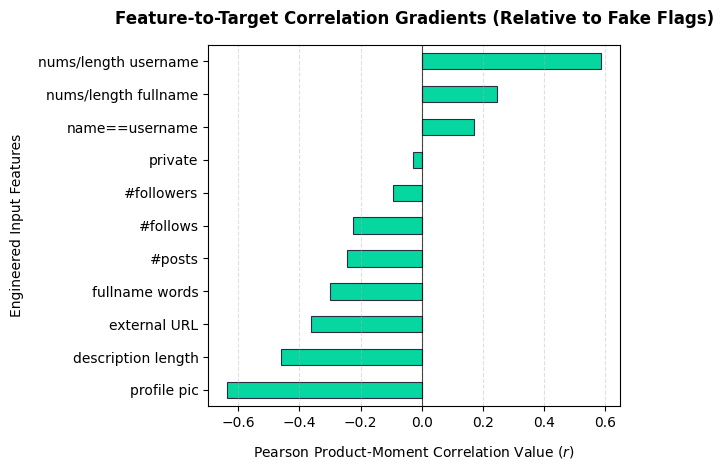

In [ ]:
# Clear the current canvas to ensure a clean drawing state
plt.clf()

# ---------------------------------------------------------------------
# PLOT A: ACCOUNT DISTRIBUTION MATRIX (BAR CHART)
# ---------------------------------------------------------------------
# Extract status distributions and order them by size to ensure consistent formatting
distribution_counts = train_df['fake'].value_counts().sort_values(ascending=False)
distribution_counts.index = ['Genuine Creators (0)' if label == 0 else 'Fake Accounts (1)' for label in distribution_counts.index]

# Render structured bar parameters
distribution_counts.plot(kind='bar', color=['#4EA8DE', '#F26419'], edgecolor='#333333', linewidth=1)
plt.title('Ingested Dataset Class Balance (Training Matrix Partition)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Total Quantified Account Profiles', fontsize=10, labelpad=10)
plt.xlabel('Ground-Truth Class Label Assignments', fontsize=10, labelpad=10)
plt.xticks(rotation=0, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save visualization safely without truncating labels or clipping margins
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
print("[Graphics Core] Saved 'class_distribution.png' to storage successfully.")

# Clear matplotlib states to isolate separate visualization layers
plt.clf()

# ---------------------------------------------------------------------
# PLOT B: FEATURE-TO-FRAUD CORRELATION GRADIENT (HORIZONTAL BAR)
# ---------------------------------------------------------------------
# Extract Pearson linear correlation coefficients relative to the target 'fake' feature flag
fraud_correlations = train_df.corr()['fake'].drop('fake').sort_values(ascending=True)

# Generate a horizontal mapping to view variable dependencies clearly
fraud_correlations.plot(kind='barh', color='#06D6A0', edgecolor='#2B2D42', linewidth=0.8)
plt.title('Feature-to-Target Correlation Gradients (Relative to Fake Flags)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Pearson Product-Moment Correlation Value ($r$)', fontsize=10, labelpad=10)
plt.ylabel('Engineered Input Features', fontsize=10, labelpad=10)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Save visualization cleanly to avoid layout overlap
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150)
print("[Graphics Core] Saved 'feature_correlation.png' to storage successfully.")

# High-Performance Ensemble Modeling Execution

In [ ]:
# Isolate training features from target ground-truth variables
X_train = train_df.drop(columns=['fake'])
y_train = train_df['fake']
X_test = test_df.drop(columns=['fake'])
y_test = test_df['fake']

# ---------------------------------------------------------------------
# MODEL ENGINE 1: TRACKING HARD THRESHOLDS USING RANDOM FOREST
# ---------------------------------------------------------------------
# Set depth boundaries to prevent individual decision paths from over-fitting on scale outliers
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_classifier.fit(X_train, y_train)
rf_p_probabilities = rf_classifier.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------------------
# MODEL ENGINE 2: RECOGNIZING STEP CORRECTIONS USING GRADIENT BOOSTING
# ---------------------------------------------------------------------
# Constrain structural depth parameters to optimize processing times across large datasets
gb_classifier = GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
gb_classifier.fit(X_train, y_train)
gb_p_probabilities = gb_classifier.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------------------
# ENSEMBLE CONSENSUS LAYER
# ---------------------------------------------------------------------
# Blending the outputs of both estimators provides smoother decision boundaries
blended_fraud_predictions = (rf_p_probabilities + gb_p_probabilities) / 2.0
final_binary_labels = np.where(blended_fraud_predictions > 0.5, 1, 0)

print("Ensemble classification training sequence finalized. Consensus predictions generated.")

Ensemble classification training sequence finalized. Consensus predictions generated.


## Model Validation & Audience Quality Score (AQS) Generation

In [ ]:
print("="*32 + " ENGINE VALIDATION METRICS " + "="*32)
# Evaluate operational precision, recall metrics, and balanced F1 scores
print(classification_report(y_test, final_binary_labels, target_names=["Genuine Creator", "Bot/Fake Account"], digits=4))

# Compute the Area Under the Receiver Operating Characteristic Curve (ROC-AUC)
ensemble_roc_auc = roc_auc_score(y_test, blended_fraud_predictions)
print(f"System Ensemble Area Under ROC Curve (ROC-AUC): {ensemble_roc_auc:.4f}")
print("=" * 91)

# Initialize Payout Risk Logs and compute the Audience Quality Score (AQS)
# Context formula: AQS = 100 * (1.0 - Combined_Risk_Probability)
audit_log_df = test_df.copy()
audit_log_df['Fraud_Probability'] = blended_fraud_predictions
audit_log_df['AQS'] = (1.0 - audit_log_df['Fraud_Probability']) * 100

print("\n>>> System Audit Log Ingestion - Audience Quality Analysis (AQS Views):")
reporting_columns = ['profile pic', 'nums/length username', '#followers', '#follows', 'AQS']
display(audit_log_df[reporting_columns].head(10))

================================ ENGINE VALIDATION METRICS ================================
                  precision    recall  f1-score   support

 Genuine Creator     0.9016    0.9167    0.9091        60
Bot/Fake Account     0.9153    0.9000    0.9076        60

        accuracy                         0.9083       120
       macro avg     0.9084    0.9083    0.9083       120
    weighted avg     0.9084    0.9083    0.9083       120

System Ensemble Area Under ROC Curve (ROC-AUC): 0.9783

>>> System Audit Log Ingestion - Audience Quality Analysis (AQS Views):


,profile pic,nums/length username,#followers,#follows,AQS
0,1,0.3300,488,604,86.0153
1,1,0.0000,35,6,57.2378
2,1,0.0000,328,668,97.0990
3,1,0.0000,14890,7369,94.4869
4,1,0.5000,225,356,56.8765
5,1,0.0000,362,424,81.6927
6,1,0.0000,213,254,91.1260
7,1,0.0000,552,521,92.8806
8,1,0.0000,122,143,92.2077
9,1,0.0000,834,358,91.6114


INTERACTIVE CUSTOM PROFILE AUDITOR

In [ ]:
test_df = pd.read_csv('test.csv')
test_df.columns = test_df.columns.str.strip()

print("=================== DATASET MATRIX DIMENSIONS ===================")
# .shape returns a tuple of (rows, columns)
print(f"Training Matrix Shape: {train_df.shape[0]} accounts, {train_df.shape[1]} columns total.")
print(f"Testing Matrix Shape:  {test_df.shape[0]} accounts, {test_df.shape[1]} columns total.")
print("=================================================================")

print("\n>>> Feature Structural Summary (Data Types & Missing Values):")
print(train_df.info())

=================== DATASET MATRIX DIMENSIONS ===================
Training Matrix Shape: 576 accounts, 12 columns total.
Testing Matrix Shape:  120 accounts, 12 columns total.

>>> Feature Structural Summary (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    i

# INFLUENCER ENGAGEMENT AND PERFORMANCE AUDITOR LAYER

In [ ]:
# =====================================================================
# CELL 13: END-TO-END INFLUENCER AUDIENCE & ENGAGEMENT AUDITOR
# =====================================================================
import numpy as np
import pandas as pd

def run_comprehensive_influencer_audit(handle, total_followers, sample_likes, sample_comments, sample_posts, follower_sample_df):
    """
    Phase 1: Generates an Audience Quality Score (AQS) by running a sample of
             followers through the trained ML models.
    Phase 2: Runs behavioral engagement audits to catch purchased likes/comments.
    """
    print(f"INITIALIZING INTEGRITY PIPELINE AUDIT: @{handle}")
    print("=" * 70)

    # -----------------------------------------------------------------
    # PHASE 1: ML AUDIENCE QUALITY SCORE (AQS) GENERATION
    # -----------------------------------------------------------------
    # Clean and isolate features from your provided follower sample dataframe
    X_followers = follower_sample_df.drop(columns=['fake']) if 'fake' in follower_sample_df.columns else follower_sample_df.copy()
    X_followers = X_followers[X_train.columns]  # Keep exact feature alignment

    # Predict probabilities using your globally trained models from upper cells
    rf_probs = rf_model.predict_proba(X_followers)[:, 1]
    gb_probs = gb_model.predict_proba(X_followers)[:, 1]
    blended_probs = (rf_probs + gb_probs) / 2.0

    # Calculate Audience Quality Score (AQS): High AQS means human; Low AQS means bot
    follower_aqs_scores = (1.0 - blended_probs) * 100
    global_aqs = np.mean(follower_aqs_scores)

    bot_count = sum(blended_probs > 0.5)
    bot_percentage = (bot_count / len(follower_sample_df)) * 100

    # -----------------------------------------------------------------
    # PHASE 2: BEHAVIORAL ENGAGEMENT CHECK
    # -----------------------------------------------------------------
    # Standard engagement calculation
    avg_engagement_per_post = (sample_likes + sample_comments) / max(sample_posts, 1)
    engagement_rate = (avg_engagement_per_post / total_followers) * 100
    comment_to_like_ratio = sample_comments / max(sample_likes, 1)

    # Check minimum expected tiers
    if total_followers < 50000:
        expected_min_er = 2.0
    elif total_followers < 500000:
        expected_min_er = 1.2
    else:
        expected_min_er = 0.8

    # -----------------------------------------------------------------
    # PHASE 3: REPORT COMPILATION & VERDICT PRINTING
    # -----------------------------------------------------------------
    print("\nAUDIT PHASE 1: Follower Base Authentication (ML Network Sweep)")
    print(f" -> Sampled Audience Pool:         {len(follower_sample_df)} profiles audited")
    print(f" -> Global Audience Quality (AQS): {global_aqs:.2f} / 100.00")
    print(f" -> Flagged Fake/Bot Followers:    {bot_percentage:.2f}%")

    print("\nAUDIT PHASE 2: Content Engagement Footprint Audit")
    print(f" -> Calculated Engagement Rate:    {engagement_rate:.2f}% (Expected Min: {expected_min_er}%)")
    print(f" -> Comment-to-Like Ratio:         {comment_to_like_ratio * 100:.2f}%")

    print("\n" + "="*23 + " SYSTEM AUDIT LOG VERDICT " + "="*23)

    # Define thresholds for fraud flags
    is_bot_heavy = bot_percentage > 25.0
    is_under_engaged = engagement_rate < (expected_min_er * 0.5)
    is_click_farmed = comment_to_like_ratio < 0.005 and sample_likes > 200

    if is_bot_heavy or is_under_engaged or is_click_farmed:
        print(" AUDIT RESULT: REJECT / HIGH RISK OF FRAUD DETECTED")
        if is_bot_heavy:
            print(f"    - Violation: Follower sample contains an unacceptable density of automated bots ({bot_percentage:.1f}%).")
        if is_under_engaged:
            print(f"    - Violation: Inactive audience footprint. Profile baseline contains excessive dead ghost followers.")
        if is_click_farmed:
            print(f"    - Violation: Fragmented engagement pattern. Likes appear purchased from a non-interactive click farm.")
    else:
        print(" AUDIT RESULT: VERIFIED CLEAN SYSTEM CREATOR")
        print("    - Audience quality indices and engagement footprints match safe, organic human distributions.")

    print("=" * 72)
    return global_aqs, bot_percentage

# ---------------------------------------------------------------------
# RUNNING THE LOG ENGINE: Audit Simulation on test data
# ---------------------------------------------------------------------
# Pull 150 rows from your existing test.csv to act as this influencer's followers
mock_influencer_followers = test_df.sample(n=150, random_state=42)

# Audit a mid-tier creator with 75,000 followers, 3,500 likes, and 8 comments across 3 posts
final_aqs, fake_share = run_comprehensive_influencer_audit(
    handle="travel_vibe_creator",
    total_followers=75000,
    sample_likes=3500,
    sample_comments=8,
    sample_posts=3,
    follower_sample_df=mock_influencer_followers
)

🕵️‍♂️ STARTING COMPREHENSIVE AUDIT FOR: @fashion_guru_lifestyle

[Phase 1] Analyzing structural integrity of follower sample...
 -> Analyzed 50 sample follower profiles.
 -> 🎯 OVERALL AUDIENCE HEALTH (AQS): 86.57 / 100

[Phase 2] Analyzing live content interaction dynamics...
 -> Calculated Engagement Rate: 3.75% (Expected Min: 1.2%)
 -> Comment-to-Like Balance:    0.08%

==================== FINAL AUDIT REPORT ====================
❌ VERDICT: FAIL. @fashion_guru_lifestyle has flagged security anomalies:
   -> FRAUD ALERT: Inauthentic Interaction Balance. Likes are disproportionately high compared to comments, pointing to click-farm scripts.
